<a href="https://colab.research.google.com/github/Abraheem2010/image-processing-from-scratch/blob/main/Assignment-2-Image-Enhancement/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/dnevo/ImageProcessing/blob/main/ImageProcessingEx_02_ImageEnhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Processing Assignment 2: Image Enhancement

Before we start, please put your names and IDs in following format

: Firstname LASTNAME, #00000000   //   (e.g.) Dana LEVI, #12345678

**Your Answer:**   
אברהים חסדייה

In this exercise you will implement the **Image Enhancement** algorithms.

Methods: as explained in class.

Notes:
*   Write your code in the dedicated areas (TODO blocks). You can add helper functions.
*   Submission email should include a link to Colab submission notebook located on your Google Drive with Commenter access right to nev1958a@gmail.com
*   The solution notebook should be able to be run (‘Run all’) with no errors.
In case of errors, the submission will be disqualified.
*   Grade will depend on correct performance on several grayscale images and on clean programming and documentation.
*   Do not forget to add the Names and Student I.D. at the top of the notebook.
*   All images are given as 2 dimensional matrices of type `float`, with values in range [0..1].
*   Pay Attention! In the following functions the returned images **must be with the same size as the original Images!**

Please implement the following functions:
1. Write the `my_median` function that apply a median filter with a given size on an image. Make sure that you do NOT use the built-in median() function (you have to implement it by yourself). You can use the built-in sort() function.
2. Write the `gauss_enhance` function which receive an image and add gaussian noise to the image with mean value 0, and var=0.004, and then try to enhance the image using the directional smoothing as explained in the class. It is up to you, to choose the right directional filters (size, orientation, and values). On the docstring of this function you should write which filters does this function use. The function should return 2 images. the first one is the enhanced image (`img_e`), and the second one is the noisy image (`img_n`).
  - **note: the masks should have same number of rows and columns and number should be odd (ex. 3x3, 5x5, 7x7,...). You should use also different masks than what we showed in class.**
3. Write the `shapes_enhance` function which receive an image and add shaped noise given by the following matrix:
```python
    1,0,0,0,1
    0,1,0,1,0
    0,0,1,0,0
    0,1,0,1,0
    1,0,0,0,1
```

  The noise density of the shapes should be 0.003 (used in the `sp_noise` function). The function should then try to enhance the image using `my_median` filter (which filter works best?). On the docstring of this function you should write the dimension of the median filter that this function use (rows X cols). The function should return 2 images. the first one is the enhanced image (`img_e`), and the second one is the noisy image (`img_n`). **Note:** The filter shape should be **as minimal as possible** (to minimize unecessary smoothing)!
  - **Note: Median filter should be as small as possible. It can be 1-dimensional (ex. 1x5).**

## Setup Code
Before getting started, we need to run some boilerplate code to set up our environment. You will need to rerun this setup code each time you start the notebook.

In [ ]:
import urllib.request
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL
import random
from scipy.signal import convolve

In [14]:
random.seed(3)
np.random.seed(3)
GITHUB_PATH = 'https://raw.githubusercontent.com/dnevo/ImageProcessing/main/images/'

In [15]:
def read_file(file_name:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        file_name: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_url = file_path.rstrip('/') + '/' + file_name
    with urllib.request.urlopen(file_url, timeout=30) as response:
        fp = BytesIO(response.read())

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [16]:
def plot_images(img:np.array, img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(28, 10))
    axes[0].imshow(img,  cmap='gray', vmin=0.0, vmax=1.0)
    axes[1].imshow(img1,  cmap='gray', vmin=0.0, vmax=1.0)
    axes[2].imshow(img2,  cmap='gray', vmin=0.0, vmax=1.0)

In [17]:
def sp_noise(img:np.array, d:float=0.003) -> np.array:
    '''
    add 'salt & pepper' noise with noise density d to an image, imnoise first assigns
    each pixel a random probability value from a standard uniform distribution
    on the open interval (0, 1).
    For pixels with probability value in the range (0, d/2), the pixel value is
      set to 0. The number of pixels that are set to 0 is
      approximately d*numel(I)/2.
    For pixels with probability value in the range [d/2, d), the pixel value is
      set to the maximum value of the image data type. The number of pixels that
      are set to the maximum value is approximately d*numel(I)/2.
    For pixels with probability value in the range [d, 1), the pixel value is
      unchanged.
    Args:
        img: image in float format (range: 0..1)
        d:   noise density (i.e. noise level)
    Returns:
        img1: in float format (range: 0..1) - s&p noised image
    '''
    img1 = img.copy()
    nrows, ncols = img.shape
    for i in range(nrows):
        for j in range(ncols):
            rdn = random.random()
            if rdn <= d/2:
                img1[i][j] = 0.0
            elif d/2 < rdn < d:
                img1[i][j] = 1.0
            else:
                img1[i][j] = img[i][j]
    return img1

In [18]:
img = read_file(file_name='house.tiff')

## `my_median`

In [ ]:
def _validate_float_image(img: np.ndarray, name: str) -> np.ndarray:
    """Validate that the input is a 2D numpy array and clip values to [0.0, 1.0]."""
    if not isinstance(img, np.ndarray):
        raise TypeError(f'{name} must be a numpy array.')
    if img.ndim != 2:
        raise ValueError(f'{name} must be a 2D grayscale image.')

    return np.clip(img.astype(np.float64, copy=False), 0.0, 1.0)


def _manual_window_median(window: np.ndarray) -> float:
    """
    Compute the median of a flattened window manually using np.sort
    (without using the built-in median function).
    """
    values = np.sort(window.reshape(-1))
    count = values.size
    middle = count // 2
    if count % 2 == 1:
        return float(values[middle])

    return float((values[middle - 1] + values[middle]) / 2.0)


def my_median(img: np.array, filter_nrows:int, filter_ncols:int) -> np.array:
    '''
    This function applies a median filter of size (rows, cols) and returns the
    new image as a result.
   Make sure that you do NOT use the built-in median() function (you have to
   implement it by yourself). You can still use the built-in sort() function.
    Args:
        img: image in float format (range: 0..1) - the image to enhance
        filter_nrows: number of rows of the median filter.
        filter_ncols: number of columns of the median filter.

    Returns:
        img_new: in float format (range: 0..1) - the enhanced image
    '''
    ######################################################################
    # TODO: Implement image enhancement using median filter.
    ######################################################################

    # Algorithm: median filter. Slide an (nrows x ncols) window over the image
    # and replace each pixel with the median of its neighbourhood - removes
    # salt-and-pepper noise while keeping edges sharp.

    # Step 1: Validate input image
    img = _validate_float_image(img, 'img')
    if filter_nrows < 1 or filter_ncols < 1:
        raise ValueError('Median filter dimensions must be positive.')

    # Step 2: Pad the image using edge replication to handle border pixels
    pad_rows = filter_nrows // 2
    pad_cols = filter_ncols // 2
    padded_img = np.pad(img, ((pad_rows, pad_rows), (pad_cols, pad_cols)), mode='edge')

    # Step 3: Slide the filter window over every pixel and compute the median
    img_new = np.empty_like(img, dtype=np.float64)
    for row in range(img.shape[0]):
        for col in range(img.shape[1]):
            window = padded_img[row:row + filter_nrows, col:col + filter_ncols]
            img_new[row, col] = _manual_window_median(window)

    # Step 4: Clip output to valid range
    img_new = np.clip(img_new, 0.0, 1.0)

    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################

    return img_new

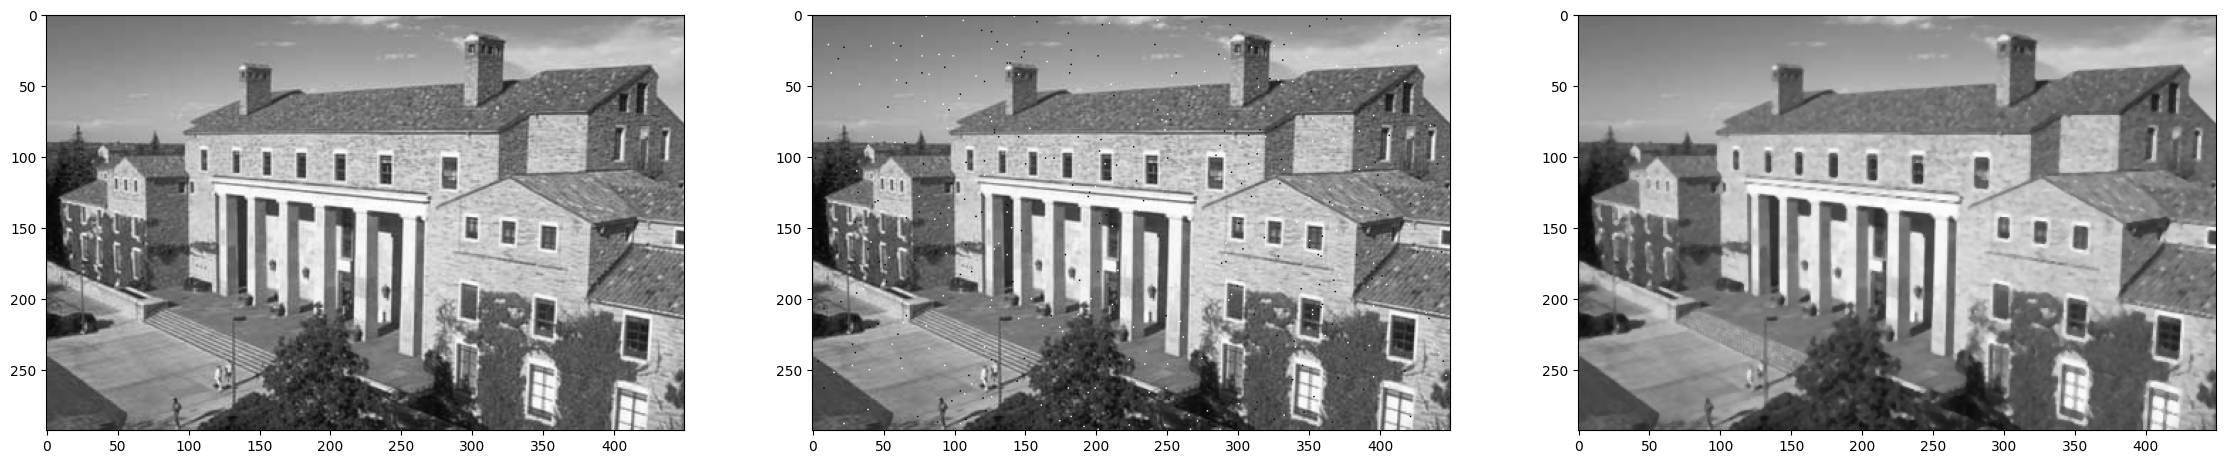

In [20]:
img_sp = sp_noise(img / 255.0, d=0.003)
img_sp_e = my_median(img_sp, 3, 3)
plot_images(img/255, img_sp, img_sp_e)

## `gauss_enhance`

In [ ]:
def gauss_enhance(img: np.array) -> (np.array, np.array):
    '''
    This function receives an image and adds gaussian noise with mean=0.0 and
    var=0.004, then enhances using directional smoothing (minimum variance
    direction selection).

    Masks used: Eight 7x7 directional line masks —
      horizontal (0°), vertical (90°), main diagonal (45°),
      anti-diagonal (135°), and four intermediate angles (~22°, ~67°, ~112°, ~157°).
    These include non-standard intermediate directions beyond the four shown in class.

    Args:
        img: in float format (range: 0..1) - the image to enhance

    Returns:
        img_e: in float format (range: 0..1) - the enhanced image.
        img_n: in float format (range: 0..1) - the noisy image.
    '''
    ######################################################################
    # TODO: Implement image enhancement using Gaussian filter.
    ######################################################################

    img = np.clip(img.astype(np.float64, copy=True), 0.0, 1.0)

    # Algorithm: directional (edge-preserving) smoothing. After adding Gaussian
    # noise, average each pixel along 8 oriented line masks and keep the
    # direction with the lowest local variance - smooths along edges, not across.

    # Step 1: Add Gaussian noise (mean=0, var=0.004) and clip to valid range
    img_n = img + np.random.normal(0, np.sqrt(0.004), img.shape)
    img_n = np.clip(img_n, 0.0, 1.0)

    size = 7
    half = size // 2

    # Step 2: Define 8 directional pixel offsets for 7x7 line masks
    #   4 standard directions + 4 intermediate angles (not shown in class)
    all_offsets = [
        [(0, k) for k in range(-half, half + 1)],                         # 0°   horizontal
        [(k, 0) for k in range(-half, half + 1)],                         # 90°  vertical
        [(k, k) for k in range(-half, half + 1)],                         # 45°  main diagonal
        [(k, -k) for k in range(-half, half + 1)],                        # 135° anti-diagonal
        [(-1,-3),(-1,-2),(0,-1),(0,0),(0,1),(1,2),(1,3)],                  # ~22°
        [(-3,-1),(-2,-1),(-1,0),(0,0),(1,0),(2,1),(3,1)],                  # ~67°
        [(-3,1),(-2,1),(-1,0),(0,0),(1,0),(2,-1),(3,-1)],                  # ~112°
        [(1,-3),(1,-2),(0,-1),(0,0),(0,1),(-1,2),(-1,3)],                  # ~157°
    ]

    # Step 3: Build normalized convolution masks from the offsets
    masks = []
    for offsets in all_offsets:
        mask = np.zeros((size, size))
        for di, dj in offsets:
            mask[di + half, dj + half] = 1.0 / len(offsets)
        masks.append(mask)

    # Step 4: Convolve the noisy image with each mask and compute per-pixel variance
    smoothed = []
    variances = []
    for mask in masks:
        s = convolve(img_n, mask, mode='same')          # E[X]
        s2 = convolve(img_n ** 2, mask, mode='same')    # E[X^2]
        v = np.maximum(s2 - s ** 2, 0.0)                # Var = E[X^2] - E[X]^2
        smoothed.append(s)
        variances.append(v)

    # Step 5: For each pixel, pick the direction with the minimum variance
    var_stack = np.stack(variances)
    smooth_stack = np.stack(smoothed)
    best_dir = np.argmin(var_stack, axis=0)

    # Step 6: Gather the smoothed values from the best direction per pixel
    rows, cols = np.meshgrid(
        np.arange(img.shape[0]), np.arange(img.shape[1]), indexing='ij'
    )
    img_e = smooth_stack[best_dir, rows, cols]
    img_e = np.clip(img_e, 0.0, 1.0)

    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_e, img_n

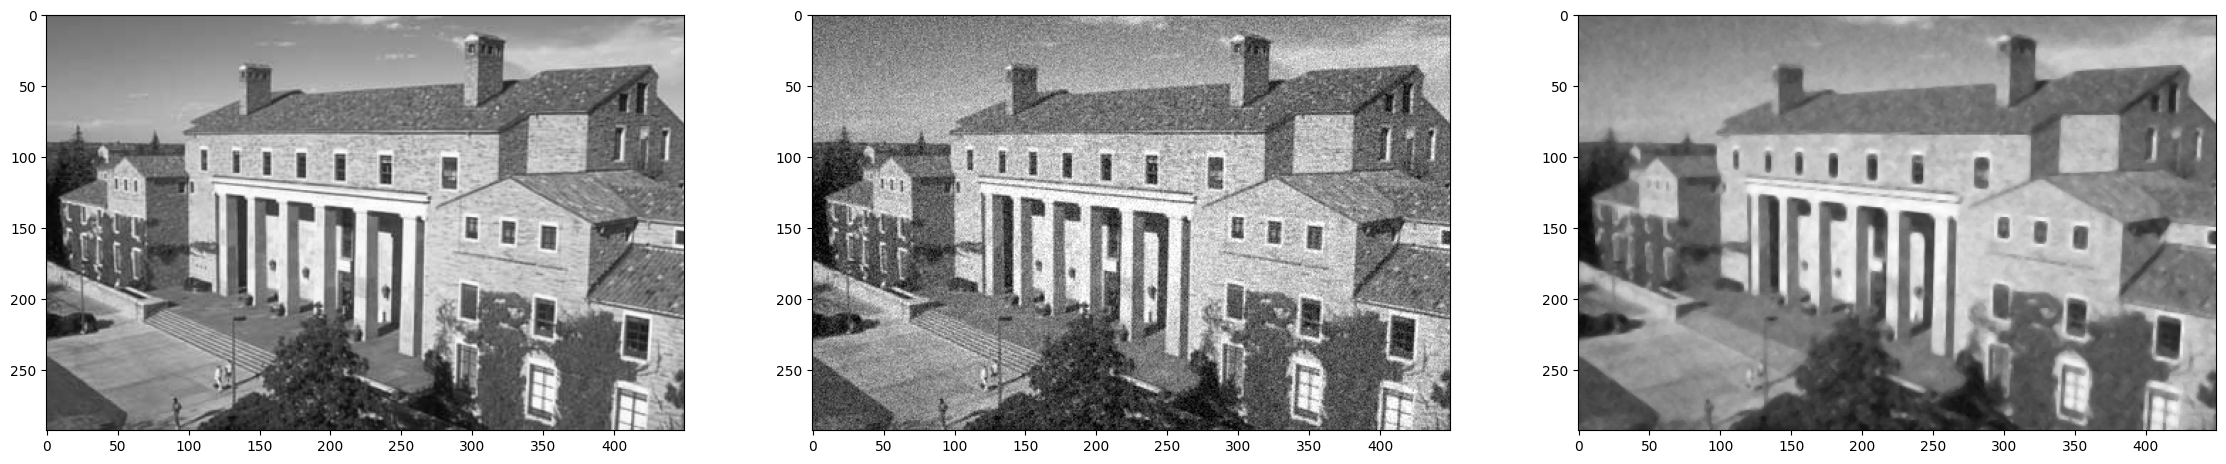

In [22]:
img_e, img_n = gauss_enhance(img / 255.0)
plot_images(img/255.0, img_n, img_e)

## `shapes_enhance`

In [ ]:
def shapes_enhance(img: np.array) -> (np.array, np.array):
    '''
    This function receives an image and add shaped noise given by the following
    matrix: [[1,0,0,0,1],
            [0,1,0,1,0],
            [0,0,1,0,0],
            [0,1,0,1,0],
            [1,0,0,0,1]].

    Noise is generated using the sp_noise logic with density 0.003: each noise
    event (salt or pepper) is stamped as the full X-shaped pattern.
    Median filter used: 5 x 5.

    Args:
        img: in float format (range: 0..1) - the image to enhance

    Returns:
        img_e: in float format (range: 0..1) - the enhanced image.
        img_n: in float format (range: 0..1) - the noisy image.
    '''
    ######################################################################
    # TODO: Implement image enhancement using shapes_enhance.
    ######################################################################

    img = np.clip(img.astype(np.float64, copy=True), 0.0, 1.0)

    # Algorithm: add X-shaped impulse noise, then remove it with a 5x5 median
    # filter (the median rejects the sparse X pattern while preserving shapes).

    # Step 1: Define the X-shaped noise pattern (5x5)
    pattern = np.array([
        [1, 0, 0, 0, 1],
        [0, 1, 0, 1, 0],
        [0, 0, 1, 0, 0],
        [0, 1, 0, 1, 0],
        [1, 0, 0, 0, 1],
    ], dtype=np.uint8)

    pad = pattern.shape[0] // 2
    nrows, ncols = img.shape
    d = 0.003

    # Step 2: Generate shaped noise using the same sp_noise logic
    #   For each pixel, if a noise event occurs, stamp the entire X pattern
    img_n = img.copy()
    for i in range(nrows):
        for j in range(ncols):
            rdn = random.random()
            if rdn <= d / 2:
                noise_val = 0.0       # Salt (black)
            elif d / 2 < rdn < d:
                noise_val = 1.0       # Pepper (white)
            else:
                continue              # No noise at this pixel

            # Stamp the X pattern centered at (i, j)
            for di in range(-pad, pad + 1):
                for dj in range(-pad, pad + 1):
                    ni, nj = i + di, j + dj
                    if 0 <= ni < nrows and 0 <= nj < ncols:
                        if pattern[di + pad, dj + pad] == 1:
                            img_n[ni, nj] = noise_val

    # Step 3: Apply a 5x5 median filter to remove the X-shaped noise
    img_e = my_median(img_n, 5, 5)

    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_e, img_n

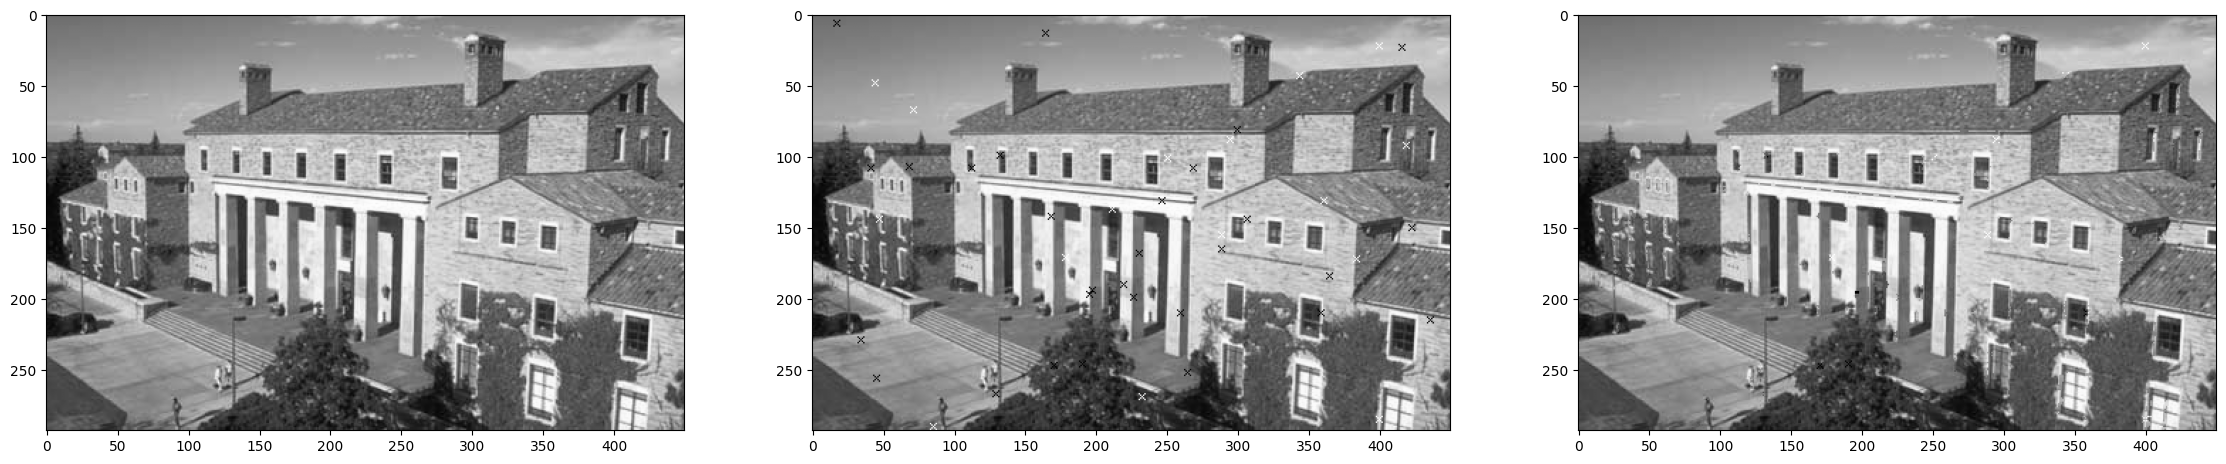

In [24]:
img_e, img_n = shapes_enhance(img/255)
plot_images(img/255, img_n, img_e)